# EMPIAR-10045: recall–$K$, NMS-radius sensitivity, and score nonstationarity

This notebook analyzes the completed **5% band-pass + $(\ell,m)$ block-QR** full-tomogram run. It never reruns whitening, template construction, or GPU scoring. Every NMS experiment reuses the same saved set of candidate coordinates and raw likelihood scores.

The primary questions are:

1. How does recall change as the retained-pick budget $K$ grows to $10N$?
2. How sensitive is that curve to NMS radii $0.1D,0.2D,0.3D,0.5D$?
3. Is the global score distribution stationary across streamed subvolumes?
4. Do annotation-containing regions and annotation-free regions exhibit different score tails?

## Experimental controls and terminology

The saved stage-7 rows are $(z,y,x,s)$ local maxima. The score $s$ is computed using one tomogram-wide whitening filter, template basis, noise variance, set of likelihood weights, and likelihood offset. There is **no per-subvolume normalization**. Consequently scores are comparable across subvolumes within this run.

NMS is downstream post-processing: changing its radius changes which fixed-score candidates survive, but it does not change their coordinates or scores.

Unless stated otherwise, the main recall curves hold the matching tolerance at its current value, $r_{match}=0.5D$, while varying only $r_{NMS}$. This isolates the NMS effect. A later section varies both parameters independently.

A subvolume is called **annotation-containing** if at least one deposited ribosome center falls inside its owned core. An **annotation-free** subvolume has no deposited center; it is not necessarily pure noise and may contain unlabeled structures, membranes, fiducials, or contamination. All uses of annotations in this notebook are post-hoc evaluation and are not part of detection.

In [ ]:
from __future__ import annotations

import csv
import html
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from scipy.spatial import cKDTree, distance
from scipy.stats import mannwhitneyu, spearmanr

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

def save_records(path, records):
    if not records:
        return
    with Path(path).open('w', newline='') as stream:
        writer = csv.DictWriter(stream, fieldnames=list(records[0]))
        writer.writeheader()
        writer.writerows(records)

def show_records(records, formats=None):
    if not records:
        display(HTML('<em>No rows</em>'))
        return
    formats = {} if formats is None else formats
    headers = list(records[0])
    rows = []
    for record in records:
        cells = []
        for header in headers:
            value = record[header]
            rendered = format(value, formats[header]) if header in formats else str(value)
            cells.append(f'<td>{html.escape(rendered)}</td>')
        rows.append('<tr>' + ''.join(cells) + '</tr>')
    heading = ''.join(f'<th>{html.escape(header)}</th>' for header in headers)
    display(HTML('<table><thead><tr>' + heading + '</tr></thead><tbody>' + ''.join(rows) + '</tbody></table>'))

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == 'experiments' else cwd
EXPERIMENTS_DIR = REPO_ROOT / 'experiments'
if str(EXPERIMENTS_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENTS_DIR))

from analyze_empiar_recall_curves import (
    exact_top_pool_order,
    incremental_recall_curve,
    spatial_hash_nms,
)

RUN_DIR = REPO_ROOT / 'results/empiar-10045-bandpass-block-qr'
OUTPUT_DIR = REPO_ROOT / 'results/empiar-10045-recall-nms-nonstationarity'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = RUN_DIR / '00_manifest.json'
CANDIDATES_PATH = RUN_DIR / '07_candidates_top4096.npy'
SAVED_PARTICLES_PATH = RUN_DIR / '08_particles_top4096_zyx.npy'

manifest = json.loads(MANIFEST_PATH.read_text())
truth_path = Path(os.environ.get('EMPIAR_10045_TRUTH', manifest['ground_truth']))
if not truth_path.is_file():
    shared_candidate = Path('/data/yoelsh/datasets/10045/pristine/data/ribosomes/AnticipatedResults/Tomograms/08/IS002_291013_008.coords')
    if shared_candidate.is_file():
        truth_path = shared_candidate
    else:
        raise FileNotFoundError('Set EMPIAR_10045_TRUTH to the tomo-08 .coords file')

candidates = np.load(CANDIDATES_PATH, mmap_mode='r')
truth_zyx = np.loadtxt(truth_path, dtype=np.float64, ndmin=2)[:, ::-1]
N = len(truth_zyx)
D_ANGSTROM = float(manifest['particle_diameter_angstrom'])
VOXEL_SIZE = float(manifest['voxel_size_angstrom'])
D_VOXELS = D_ANGSTROM / VOXEL_SIZE
RADIUS_FRACTIONS = (0.1, 0.2, 0.3, 0.5)
RADII = {fraction: fraction * D_VOXELS for fraction in RADIUS_FRACTIONS}
MAXIMUM_FACTOR = 10
MAXIMUM_PICKS = MAXIMUM_FACTOR * N
SOURCE_SHAPE = tuple(int(value) for value in manifest['volume_shape_zyx'])
CORE_SHAPE = tuple(int(value) for value in manifest['core_shape'])
GRID_SHAPE = tuple((size + core - 1) // core for size, core in zip(SOURCE_SHAPE, CORE_SHAPE))

print(f'Candidates: {len(candidates):,} rows, dtype={candidates.dtype}')
print(f'Truth particles: N={N}')
print(f'Diameter: {D_ANGSTROM:.1f} Å = {D_VOXELS:.3f} voxels')
print('Radii:', {f'{f:.1f}D': f'{r:.3f} vox' for f, r in RADII.items()})
print(f'Source={SOURCE_SHAPE}, core={CORE_SHAPE}, subvolume grid={GRID_SHAPE}')

Candidates: 5,124,744 rows, dtype=float64
Truth particles: N=454
Diameter: 270.0 Å = 118.608 voxels
Radii: {'0.1D': '11.861 vox', '0.2D': '23.722 vox', '0.3D': '35.583 vox', '0.5D': '59.304 vox'}
Source=(513, 3710, 3838), core=(186, 186, 186), subvolume grid=(3, 20, 21)


## 1. Annotation spacing and the NMS question

Before changing NMS, inspect the nearest-neighbor distances between deposited coordinates. If two annotations are closer than an NMS radius, two perfectly centered detections cannot both survive greedy NMS at that radius. This does not by itself determine the best radius, but it exposes the maximum suppression risk.

NMS fraction,radius (vox),radius (Å),close pairs,annotations with close neighbor,fraction affected
0.1,11.86,27.0,0,0,0.0%
0.2,23.72,54.0,0,0,0.0%
0.3,35.58,81.0,7,14,3.1%
0.5,59.30,135.0,61,122,26.9%


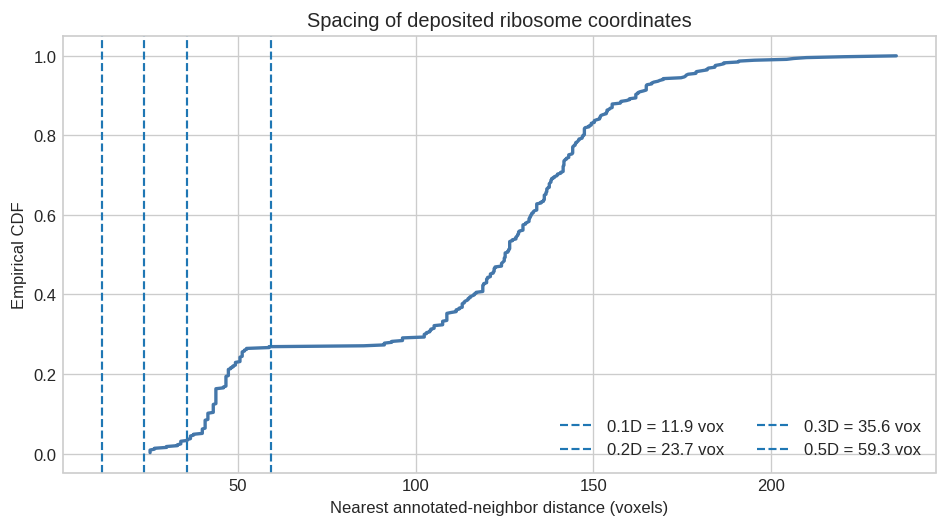

In [2]:
truth_tree = cKDTree(truth_zyx)
nearest_distances = truth_tree.query(truth_zyx, k=2)[0][:, 1]
spacing_rows = []
for fraction, radius in RADII.items():
    involved = int(np.count_nonzero(nearest_distances <= radius))
    pair_count = int(np.count_nonzero(np.triu(distance.cdist(truth_zyx, truth_zyx) <= radius, k=1)))
    spacing_rows.append({
        'NMS fraction': fraction, 'radius (vox)': radius,
        'radius (Å)': radius * VOXEL_SIZE, 'close pairs': pair_count,
        'annotations with close neighbor': involved,
        'fraction affected': involved / N,
    })
show_records(spacing_rows, {
    'NMS fraction': '.1f', 'radius (vox)': '.2f',
    'radius (Å)': '.1f', 'fraction affected': '.1%',
})
save_records(OUTPUT_DIR / 'annotation_spacing_by_radius.csv', spacing_rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.sort(nearest_distances)
ax.plot(x, np.arange(1, N + 1) / N, lw=2, color='#4477AA')
for fraction, radius in RADII.items():
    ax.axvline(radius, ls='--', lw=1.3, label=f'{fraction:.1f}D = {radius:.1f} vox')
ax.set(xlabel='Nearest annotated-neighbor distance (voxels)', ylabel='Empirical CDF',
       title='Spacing of deposited ribosome coordinates')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'annotation_nearest_neighbor_cdf.png', dpi=220)
plt.show()

## 2. Overall aggregated candidate-score distribution

The stage-7 array contains retained **local maxima**, not all score-volume voxels. Its distribution is therefore conditional on local-maximum extraction and the per-subvolume capacity of 4096. We show both raw likelihood scores and scores divided by the single global maximum. The normalization is only for visualization and does not alter ordering.

quantile,raw score (sample estimate),fraction of global maximum
0.000,-1233,-0.019905
0.001,-952.942,-0.0153838
0.010,-880.334,-0.0142117
0.100,-823.353,-0.0132918
0.500,-721.61,-0.0116493
0.900,-387.08,-0.00624882
0.990,75.9398,0.00122593
0.999,975.793,0.0157527
1.000,61944.5,1


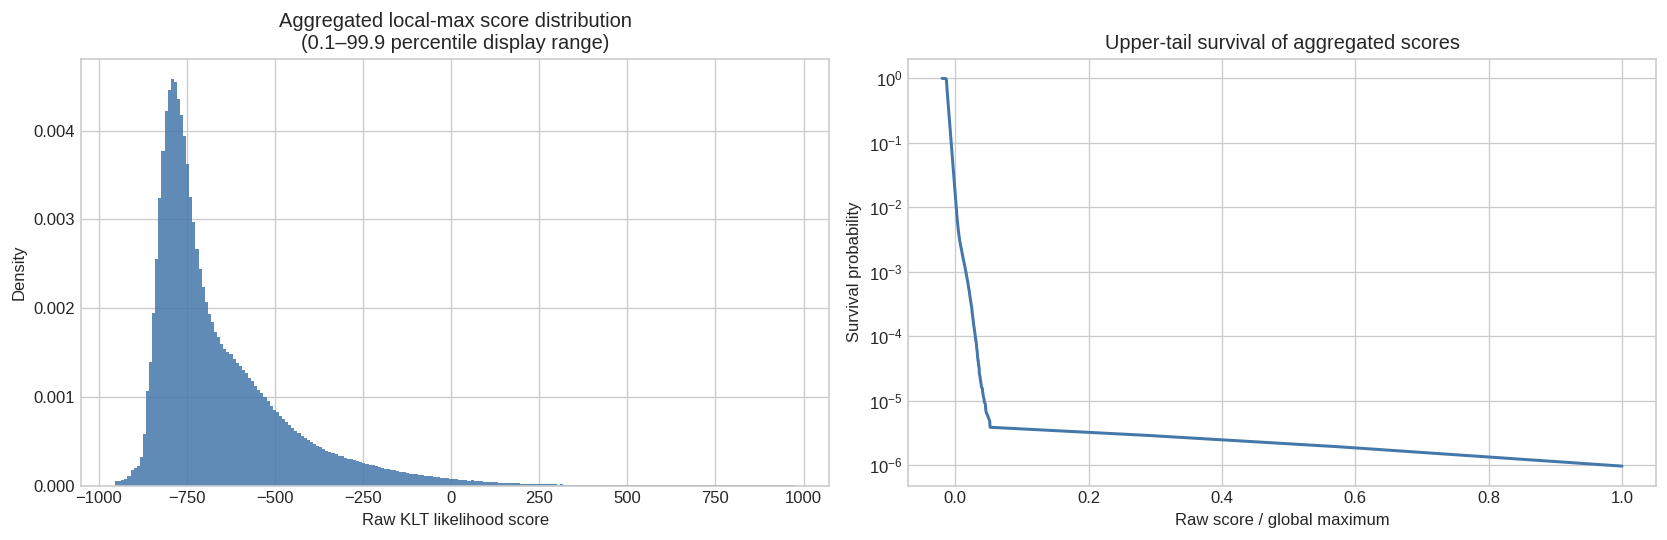

In [3]:
scores = np.asarray(candidates[:, 3])
finite = np.isfinite(scores)
scores = scores[finite]
score_maximum = float(np.max(scores))
sample_step = max(1, len(scores) // 1_000_000)
score_sample = scores[::sample_step]
quantile_levels = [0, 0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999, 1]
estimated_quantiles = np.quantile(score_sample, quantile_levels)
score_summary = [
    {'quantile': level, 'raw score (sample estimate)': value,
     'fraction of global maximum': value / score_maximum}
    for level, value in zip(quantile_levels, estimated_quantiles)
]
show_records(score_summary, {
    'quantile': '.3f', 'raw score (sample estimate)': '.6g',
    'fraction of global maximum': '.6g',
})

low, high = np.quantile(score_sample, [0.001, 0.999])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].hist(score_sample, bins=220, range=(low, high), density=True, color='#4477AA', alpha=0.85)
axes[0].set(xlabel='Raw KLT likelihood score', ylabel='Density',
            title='Aggregated local-max score distribution\n(0.1–99.9 percentile display range)')
normalized_sorted = np.sort(score_sample / score_maximum)
survival = 1 - np.arange(len(normalized_sorted)) / len(normalized_sorted)
axes[1].semilogy(normalized_sorted, survival, color='#4477AA', lw=1.8)
axes[1].set(xlabel='Raw score / global maximum', ylabel='Survival probability',
            title='Upper-tail survival of aggregated scores')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'aggregated_score_distribution.png', dpi=220)
plt.show()

## 3. Assign candidates and annotations to streamed subvolumes

Owned scoring cores form a regular grid. Assigning coordinates by integer division recovers the core responsible for each candidate. We summarize each subvolume by candidate count, maximum score, and score quantiles. Candidate-level pooled histograms are supplemented by per-subvolume statistics so dense regions do not dominate the conclusion.

In [4]:
def linear_subvolume_ids(coordinates):
    grid_coordinates = np.floor_divide(coordinates.astype(np.int64), np.asarray(CORE_SHAPE))
    grid_coordinates = np.minimum(grid_coordinates, np.asarray(GRID_SHAPE) - 1)
    return np.ravel_multi_index(grid_coordinates.T, GRID_SHAPE)

candidate_subvolume = linear_subvolume_ids(np.asarray(candidates[:, :3]))
truth_subvolume = linear_subvolume_ids(truth_zyx)
subvolume_count = int(np.prod(GRID_SHAPE))
truth_counts = np.bincount(truth_subvolume, minlength=subvolume_count)
candidate_counts = np.bincount(candidate_subvolume, minlength=subvolume_count)

sort_order = np.argsort(candidate_subvolume, kind='stable')
sorted_ids = candidate_subvolume[sort_order]
boundaries = np.r_[0, np.flatnonzero(np.diff(sorted_ids)) + 1, len(sorted_ids)]
q50 = np.full(subvolume_count, np.nan)
q90 = np.full(subvolume_count, np.nan)
q99 = np.full(subvolume_count, np.nan)
maximum = np.full(subvolume_count, np.nan)
for start, stop in zip(boundaries[:-1], boundaries[1:]):
    subvolume_id = int(sorted_ids[start])
    values = np.asarray(candidates[sort_order[start:stop], 3])
    q50[subvolume_id], q90[subvolume_id], q99[subvolume_id] = np.quantile(values, [0.5, 0.9, 0.99])
    maximum[subvolume_id] = np.max(values)

grid_coordinates = np.column_stack(np.unravel_index(np.arange(subvolume_count), GRID_SHAPE))
group_names = np.where(truth_counts > 0, 'annotation-containing', 'annotation-free')
subvolume_records = [
    {
        'subvolume_id': index, 'grid_z': int(grid_coordinates[index, 0]),
        'grid_y': int(grid_coordinates[index, 1]), 'grid_x': int(grid_coordinates[index, 2]),
        'candidate_count': int(candidate_counts[index]), 'truth_count': int(truth_counts[index]),
        'score_q50': float(q50[index]), 'score_q90': float(q90[index]),
        'score_q99': float(q99[index]), 'score_max': float(maximum[index]),
        'group': group_names[index],
    }
    for index in range(subvolume_count)
]
save_records(OUTPUT_DIR / 'subvolume_score_summary.csv', subvolume_records)
group_summary = []
for group in ('annotation-free', 'annotation-containing'):
    mask = group_names == group
    group_summary.append({
        'group': group, 'subvolumes': int(np.count_nonzero(mask)),
        'candidates': int(np.sum(candidate_counts[mask])),
        'median_q99': float(np.nanmedian(q99[mask])),
        'median_max': float(np.nanmedian(maximum[mask])),
        'mean_truth_count': float(np.mean(truth_counts[mask])),
    })
show_records(group_summary, {'median_q99': '.6g', 'median_max': '.6g', 'mean_truth_count': '.3f'})

group,subvolumes,candidates,median_q99,median_max,mean_truth_count
annotation-free,934,3789448,-559.523,-415.958,0.000
annotation-containing,326,1335296,-250.407,-61.0909,1.393


## 4. Annotation-containing versus annotation-free score distributions

The left panel pools candidate maxima and answers what scores a randomly selected retained maximum receives. The right panels use one statistic per subvolume and therefore answer whether entire regions have systematically elevated score tails. Mann–Whitney and Spearman statistics are descriptive post-hoc diagnostics, not detector inputs.

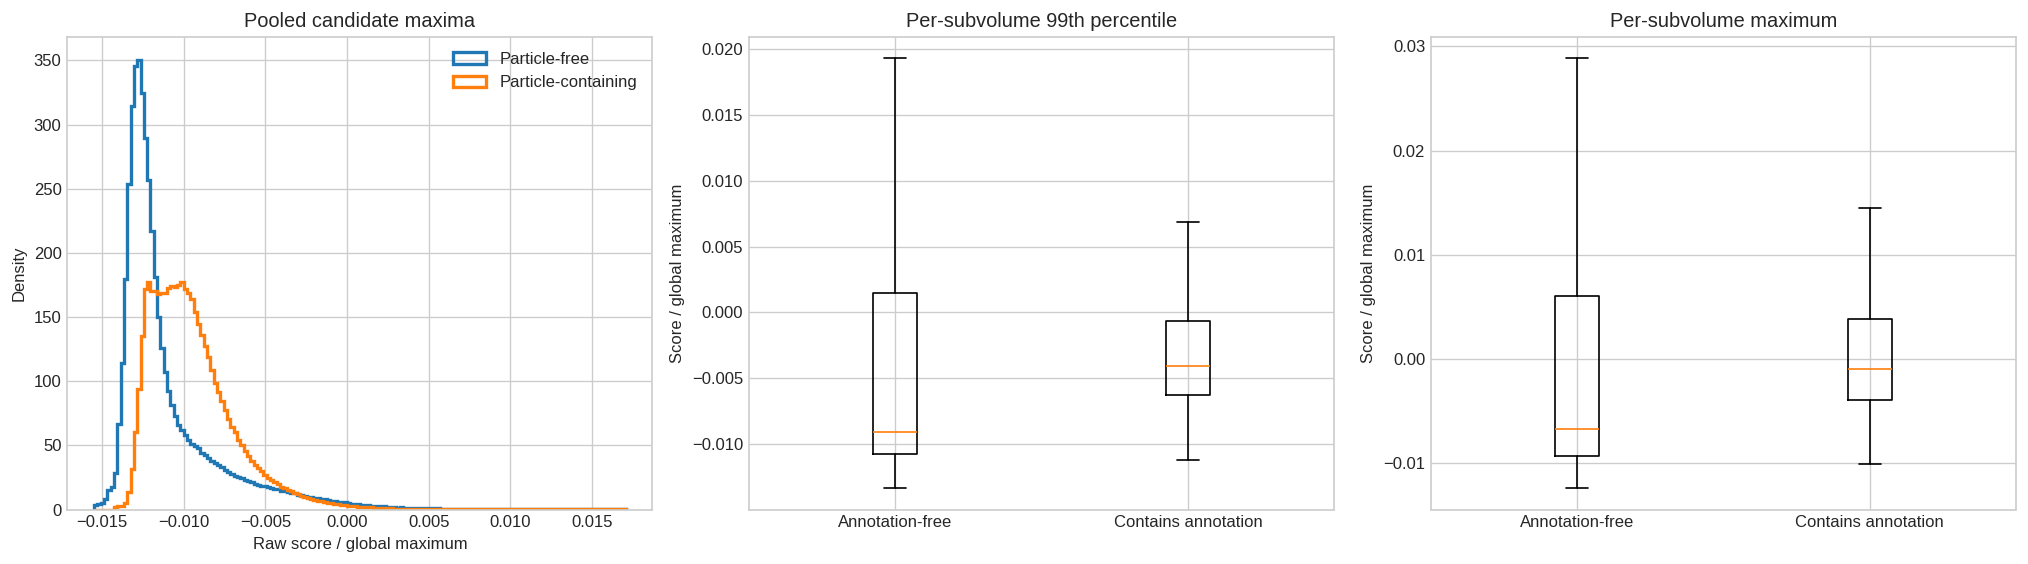

Mann–Whitney q99: U=196039.0, p=9.74e-15
Spearman(truth count, q99): rho=0.226, p=5.39e-16


In [20]:
signal_subvolumes = truth_counts > 0
candidate_signal_mask = signal_subvolumes[candidate_subvolume]
annotation_scores = np.asarray(candidates[candidate_signal_mask, 3])
free_scores = np.asarray(candidates[~candidate_signal_mask, 3])
annotation_sample = annotation_scores[::max(1, len(annotation_scores) // 500_000)] / score_maximum
free_sample = free_scores[::max(1, len(free_scores) // 500_000)] / score_maximum
pooled_low = min(np.quantile(annotation_sample, 0.001), np.quantile(free_sample, 0.001))
pooled_high = max(np.quantile(annotation_sample, 0.999), np.quantile(free_sample, 0.999))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].hist(free_sample, bins=160, range=(pooled_low, pooled_high), density=True,
             histtype='step', lw=2, label='Particle-free')
axes[0].hist(annotation_sample, bins=160, range=(pooled_low, pooled_high), density=True,
             histtype='step', lw=2, label='Particle-containing')
axes[0].set(xlabel='Raw score / global maximum', ylabel='Density', title='Pooled candidate maxima')
axes[0].legend()

group_order = ['annotation-free', 'annotation-containing']
for axis, values, title in zip(axes[1:], [q99, maximum],
                               ['Per-subvolume 99th percentile', 'Per-subvolume maximum']):
    data = [values[(group_names == group) & np.isfinite(values)] / score_maximum
            for group in group_order]
    axis.boxplot(data, tick_labels=['Annotation-free', 'Contains annotation'], showfliers=False)
    axis.set(ylabel='Score / global maximum', title=title)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'score_distributions_by_annotation_group.png', dpi=220)
plt.show()

valid = np.isfinite(q99)
u_test = mannwhitneyu(q99[valid & signal_subvolumes], q99[valid & ~signal_subvolumes], alternative='two-sided')
rho, rho_p = spearmanr(truth_counts[valid], q99[valid])
print(f'Mann–Whitney q99: U={u_test.statistic:.1f}, p={u_test.pvalue:.3g}')
print(f'Spearman(truth count, q99): rho={rho:.3f}, p={rho_p:.3g}')

## 5. Spatial nonstationarity maps

Each heatmap shows the per-subvolume 99th-percentile score on one $z$ core slab. White circles mark subvolumes containing at least one annotation; circle area increases with annotation count. Large coherent score changes across the map indicate that a single global likelihood scale is being applied to statistically nonstationary data.

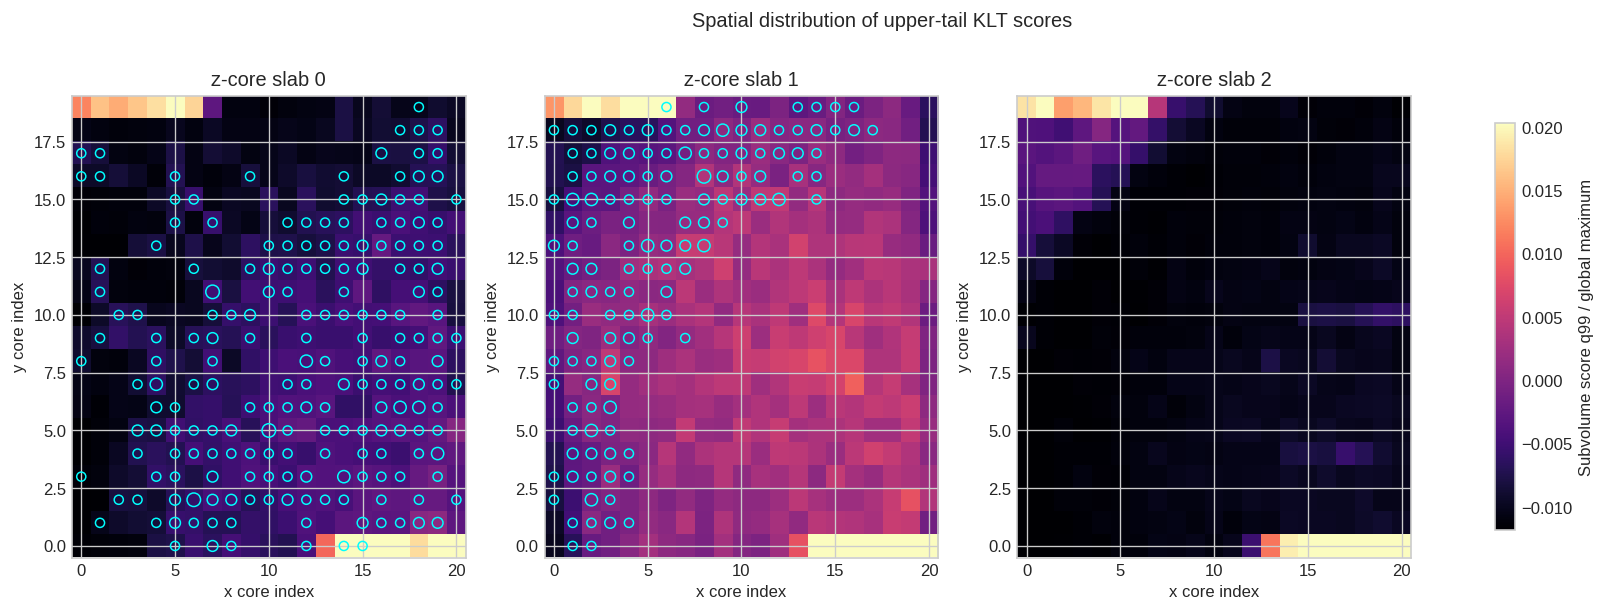

In [6]:
q99_grid = (q99 / score_maximum).reshape(GRID_SHAPE)
truth_grid = truth_counts.reshape(GRID_SHAPE)
finite_q99 = q99_grid[np.isfinite(q99_grid)]
vmin, vmax = np.quantile(finite_q99, [0.02, 0.98])
fig, axes = plt.subplots(1, GRID_SHAPE[0], figsize=(6 * GRID_SHAPE[0], 5), squeeze=False)
for z_index, axis in enumerate(axes[0]):
    image = axis.imshow(q99_grid[z_index], origin='lower', cmap='magma', vmin=vmin, vmax=vmax, aspect='auto')
    yy, xx = np.nonzero(truth_grid[z_index] > 0)
    axis.scatter(xx, yy, s=18 + 12 * truth_grid[z_index, yy, xx], facecolors='none',
                 edgecolors='cyan', linewidths=0.9, label='Contains annotation')
    axis.set(title=f'z-core slab {z_index}', xlabel='x core index', ylabel='y core index')
fig.colorbar(image, ax=axes.ravel().tolist(), label='Subvolume score q99 / global maximum', shrink=0.88)
fig.suptitle('Spatial distribution of upper-tail KLT scores', y=1.02)
fig.savefig(OUTPUT_DIR / 'subvolume_q99_spatial_maps.png', dpi=220, bbox_inches='tight')
plt.show()

In [7]:
hotspot_indices = np.argsort(np.nan_to_num(q99, nan=-np.inf))[-25:][::-1]
hotspots = []
for index in hotspot_indices:
    z_index, y_index, x_index = grid_coordinates[index]
    hotspots.append({
        'subvolume_id': int(index), 'grid_z': int(z_index), 'grid_y': int(y_index),
        'grid_x': int(x_index), 'start_z': int(z_index * CORE_SHAPE[0]),
        'start_y': int(y_index * CORE_SHAPE[1]), 'start_x': int(x_index * CORE_SHAPE[2]),
        'candidate_count': int(candidate_counts[index]), 'truth_count': int(truth_counts[index]),
        'score_q99': float(q99[index]), 'score_max': float(maximum[index]),
        'group': group_names[index],
    })
show_records(hotspots, {'score_q99': '.4g', 'score_max': '.4g'})
save_records(OUTPUT_DIR / 'top25_score_hotspot_subvolumes.csv', hotspots)

subvolume_id,grid_z,grid_y,grid_x,start_z,start_y,start_x,candidate_count,truth_count,score_q99,score_max,group
435,1,0,15,186,0,2790,4096,0,2291,3669,annotation-free
436,1,0,16,186,0,2976,4096,0,2054,3319,annotation-free
434,1,0,14,186,0,2604,4096,0,1950,2746,annotation-free
439,1,0,19,186,0,3534,3302,0,1911,2703,annotation-free
20,0,0,20,0,0,3720,679,0,1891,2440,annotation-free
15,0,0,15,0,0,2790,4096,1,1811,2542,annotation-containing
19,0,0,19,0,0,3534,2053,0,1718,1999,annotation-free
16,0,0,16,0,0,2976,4096,0,1620,2590,annotation-free
1245,2,19,6,372,3534,1116,4096,0,1612,2476,annotation-free
14,0,0,14,0,0,2604,4096,1,1603,2168,annotation-containing


## 6. Recompute global NMS for four radii

The earlier analysis proved that the exact top 1.6 million raw-score candidates contain at least 4540 survivors for $0.5D$. Smaller NMS radii can only suppress fewer candidates, so the same exact ordered pool is sufficient for every radius below. The saved $0.5D$ top-454 prefix is reproduced as a regression check.

In [8]:
ORDERED_POOL_SIZE = 1_600_000
ordered_indices = exact_top_pool_order(candidates, ORDERED_POOL_SIZE)
print(f'Exact ordered pool including cutoff ties: {len(ordered_indices):,}')

ranked_by_nms = {}
for fraction, radius in RADII.items():
    cache_path = OUTPUT_DIR / f'ranked_nms_{fraction:.1f}D_top10N.npy'
    if cache_path.is_file():
        ranked = np.load(cache_path)
    else:
        ranked = spatial_hash_nms(candidates, ordered_indices, radius=radius, max_picks=MAXIMUM_PICKS)
        np.save(cache_path, ranked)
    if len(ranked) != MAXIMUM_PICKS:
        raise RuntimeError(f'{fraction:.1f}D NMS retained only {len(ranked)} picks')
    ranked_by_nms[fraction] = ranked
    print(f'{fraction:.1f}D NMS: retained {len(ranked):,} picks; score floor={ranked[-1, 3]:.6g}')

saved = np.load(SAVED_PARTICLES_PATH)
assert np.array_equal(ranked_by_nms[0.5][:len(saved), :3], saved[:, :3])
print('Regression check passed: 0.5D NMS reproduces all saved top-454 coordinates.')

Exact ordered pool including cutoff ties: 1,600,001
0.1D NMS: retained 4,540 picks; score floor=412.011
0.2D NMS: retained 4,540 picks; score floor=109.401
0.3D NMS: retained 4,540 picks; score floor=-64.5066
0.5D NMS: retained 4,540 picks; score floor=-484.751
Regression check passed: 0.5D NMS reproduces all saved top-454 coordinates.


## 7. Recall–$K$ curves with fixed $0.5D$ matching tolerance

Matching is maximum-cardinality and one-to-one: one prediction cannot satisfy two annotations. Each panel corresponds to one NMS radius and extends to $10N=4540$ retained picks. Because matching remains fixed, differences between panels are caused solely by NMS.

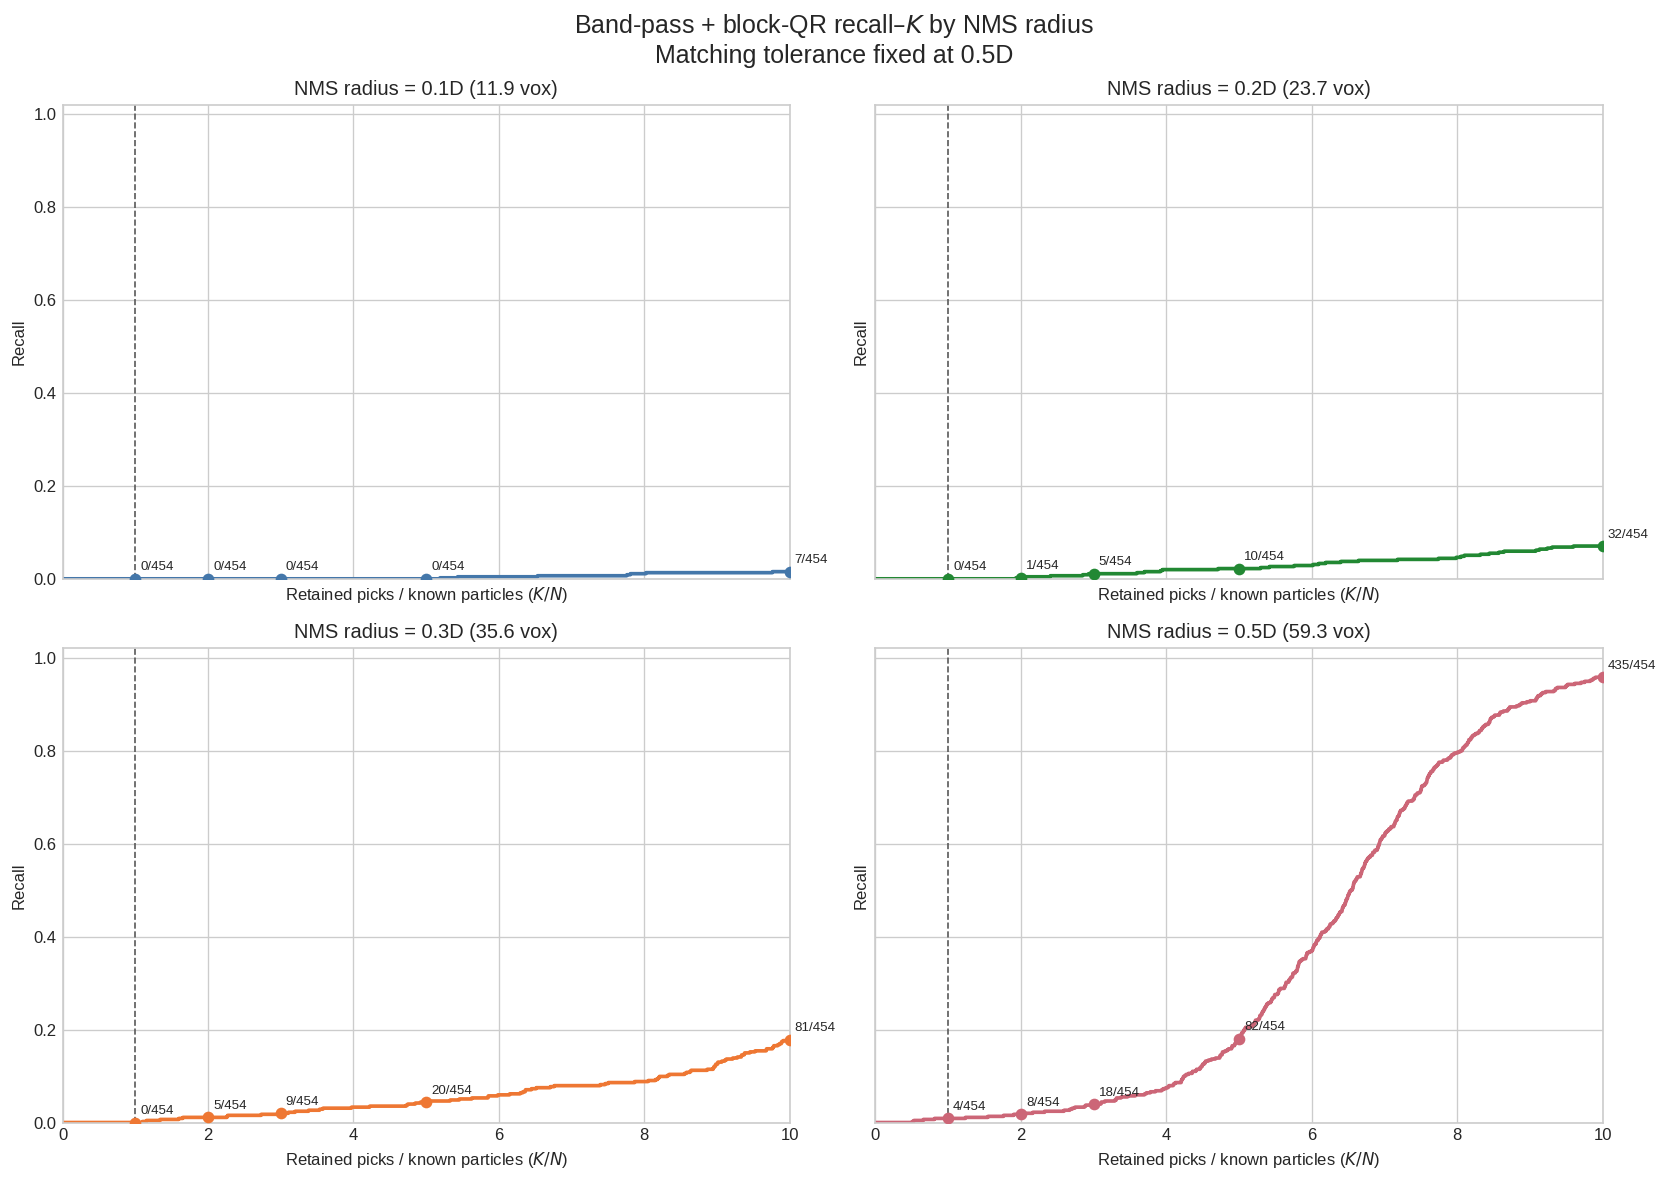

In [9]:
PRIMARY_MATCH_FRACTION = 0.5
primary_match_radius = RADII[PRIMARY_MATCH_FRACTION]
primary_curves = {
    fraction: incremental_recall_curve(ranked, truth_zyx, primary_match_radius)
    for fraction, ranked in ranked_by_nms.items()
}
ranks = np.arange(1, MAXIMUM_PICKS + 1)
factors = ranks / N
colors = {0.1: '#4477AA', 0.2: '#228833', 0.3: '#EE7733', 0.5: '#CC6677'}
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
for axis, (fraction, matches) in zip(axes.ravel(), primary_curves.items()):
    recall = matches / N
    axis.plot(factors, recall, lw=2.2, color=colors[fraction])
    axis.axvline(1, color='0.35', ls='--', lw=1)
    for factor in (1, 2, 3, 5, 10):
        index = factor * N - 1
        axis.scatter(factor, recall[index], color=colors[fraction], zorder=3)
        axis.annotate(f'{matches[index]}/{N}', (factor, recall[index]),
                      xytext=(3, 5), textcoords='offset points', fontsize=8)
    axis.set(title=f'NMS radius = {fraction:.1f}D ({RADII[fraction]:.1f} vox)',
             xlabel='Retained picks / known particles ($K/N$)', ylabel='Recall',
             xlim=(0, 10), ylim=(0, 1.02))
fig.suptitle('Band-pass + block-QR recall–$K$ by NMS radius\nMatching tolerance fixed at 0.5D', fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'recall_k_separate_nms_radii_match_0.5D.png', dpi=220)
plt.show()

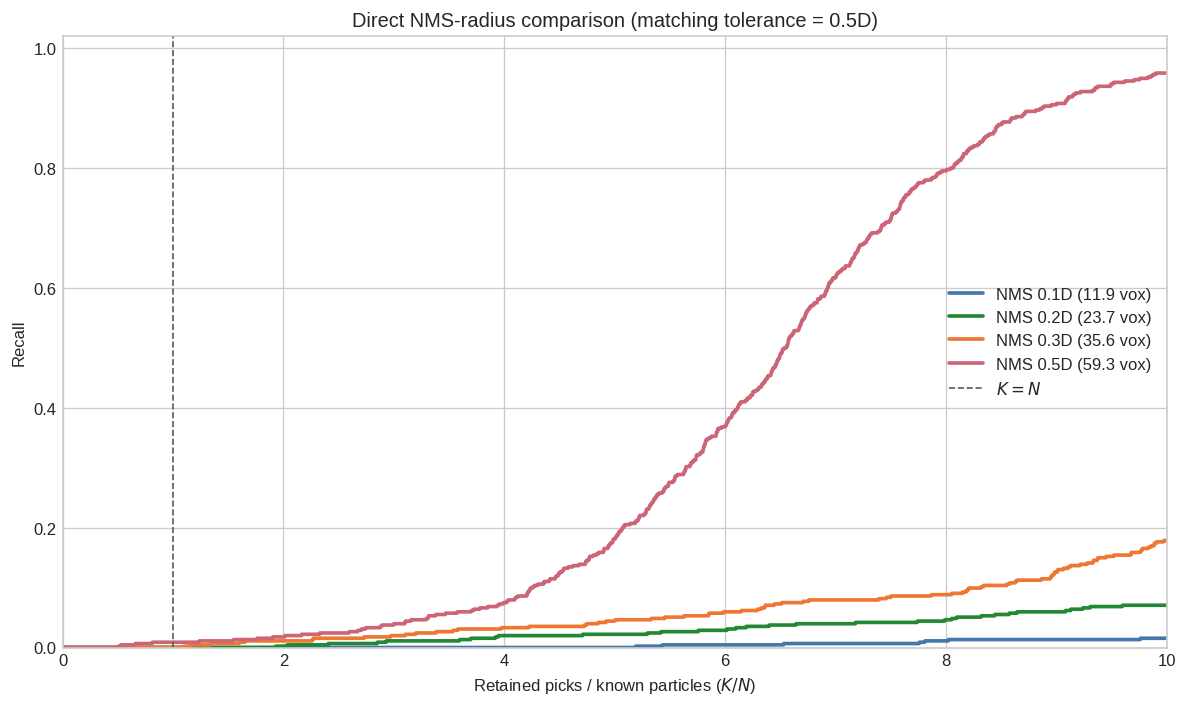

NMS radius,K/N,K,matched,recall,precision
0.1D,1,454,0,0.0%,0.0%
0.1D,2,908,0,0.0%,0.0%
0.1D,3,1362,0,0.0%,0.0%
0.1D,5,2270,0,0.0%,0.0%
0.1D,10,4540,7,1.5%,0.2%
0.2D,1,454,0,0.0%,0.0%
0.2D,2,908,1,0.2%,0.1%
0.2D,3,1362,5,1.1%,0.4%
0.2D,5,2270,10,2.2%,0.4%
0.2D,10,4540,32,7.0%,0.7%


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
for fraction, matches in primary_curves.items():
    ax.plot(factors, matches / N, lw=2.2, color=colors[fraction],
            label=f'NMS {fraction:.1f}D ({RADII[fraction]:.1f} vox)')
ax.axvline(1, color='0.35', ls='--', lw=1, label='$K=N$')
ax.set(xlabel='Retained picks / known particles ($K/N$)', ylabel='Recall',
       title='Direct NMS-radius comparison (matching tolerance = 0.5D)',
       xlim=(0, 10), ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'recall_k_nms_radius_overlay_match_0.5D.png', dpi=220)
plt.show()

checkpoint_rows = []
for nms_fraction, matches in primary_curves.items():
    for factor in (1, 2, 3, 5, 10):
        k = factor * N
        matched = int(matches[k - 1])
        checkpoint_rows.append({
            'NMS radius': f'{nms_fraction:.1f}D', 'K/N': factor, 'K': k,
            'matched': matched, 'recall': matched / N, 'precision': matched / k,
        })
save_records(OUTPUT_DIR / 'recall_checkpoints_match_0.5D.csv', checkpoint_rows)
show_records(checkpoint_rows, {'recall': '.1%', 'precision': '.1%'})

## 8. Separate NMS sensitivity from matching-tolerance sensitivity

A large matching tolerance may inflate high-$K$ recall, whereas a large NMS radius may suppress nearby candidates. The following heatmaps vary both independently. This is the most defensible way to report sensitivity without conflating duplicate suppression with the definition of a successful localization.

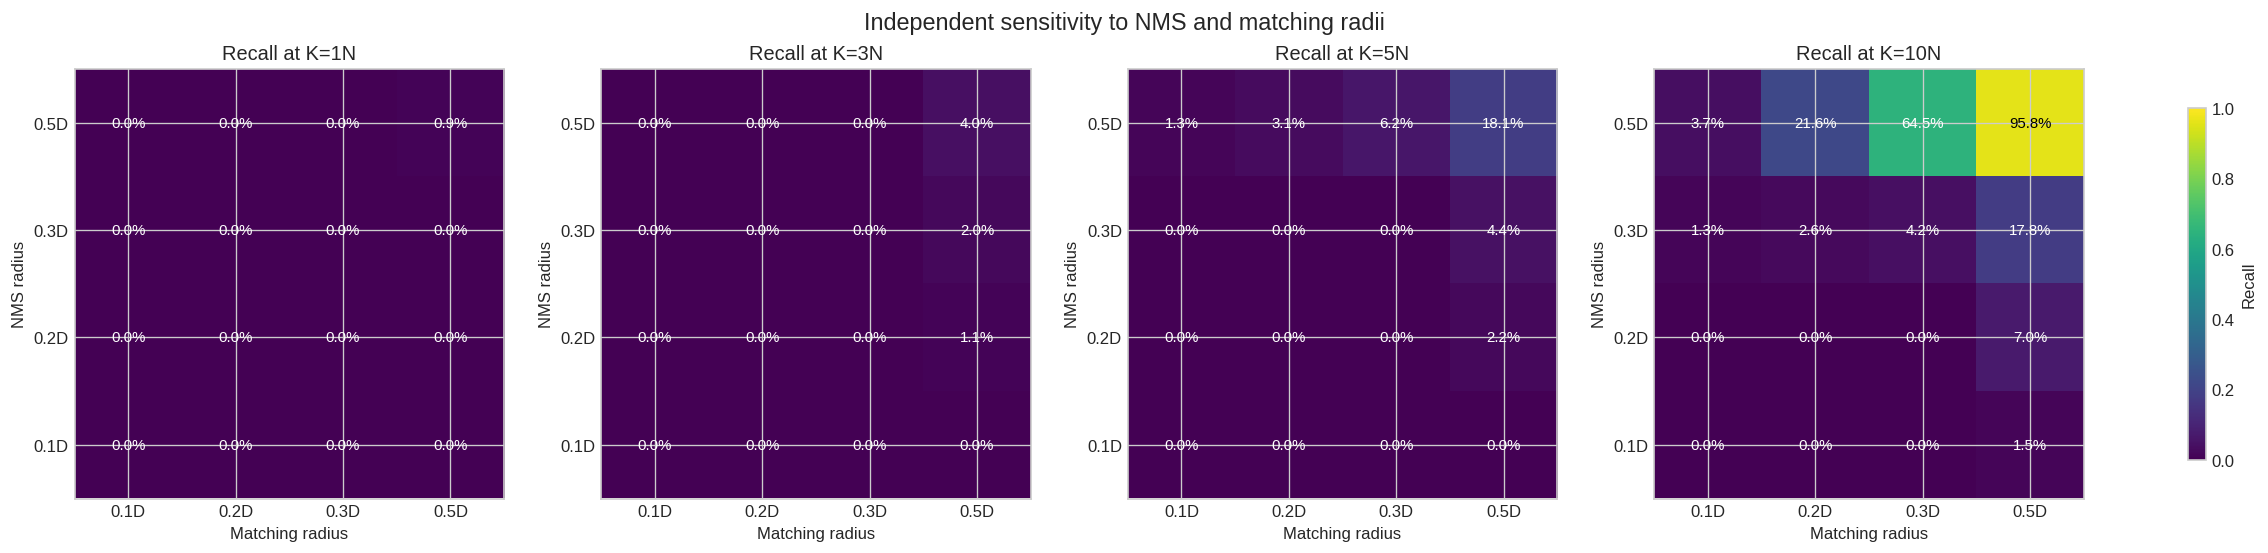

In [11]:
all_curves = {}
for nms_fraction, ranked in ranked_by_nms.items():
    for match_fraction, match_radius in RADII.items():
        all_curves[(nms_fraction, match_fraction)] = incremental_recall_curve(
            ranked, truth_zyx, match_radius
        )

sensitivity_rows = []
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5), constrained_layout=True)
for axis, factor in zip(axes, (1, 3, 5, 10)):
    matrix = np.empty((len(RADIUS_FRACTIONS), len(RADIUS_FRACTIONS)))
    for row, nms_fraction in enumerate(RADIUS_FRACTIONS):
        for column, match_fraction in enumerate(RADIUS_FRACTIONS):
            matrix[row, column] = all_curves[(nms_fraction, match_fraction)][factor * N - 1] / N
            sensitivity_rows.append({
                'K/N': factor, 'K': factor * N, 'NMS fraction': nms_fraction,
                'matching fraction': match_fraction, 'recall': matrix[row, column],
            })
    image = axis.imshow(matrix, vmin=0, vmax=1, cmap='viridis', origin='lower')
    for row in range(len(RADIUS_FRACTIONS)):
        for column in range(len(RADIUS_FRACTIONS)):
            axis.text(column, row, f'{matrix[row, column]:.1%}', ha='center', va='center',
                      color='white' if matrix[row, column] < 0.65 else 'black', fontsize=9)
    axis.set_xticks(range(len(RADIUS_FRACTIONS)), [f'{f:.1f}D' for f in RADIUS_FRACTIONS])
    axis.set_yticks(range(len(RADIUS_FRACTIONS)), [f'{f:.1f}D' for f in RADIUS_FRACTIONS])
    axis.set(xlabel='Matching radius', ylabel='NMS radius', title=f'Recall at K={factor}N')
fig.colorbar(image, ax=axes, label='Recall', shrink=0.82)
fig.suptitle('Independent sensitivity to NMS and matching radii', fontsize=14)
fig.savefig(OUTPUT_DIR / 'nms_matching_radius_sensitivity_heatmaps.png', dpi=220)
save_records(OUTPUT_DIR / 'nms_matching_radius_sensitivity.csv', sensitivity_rows)
plt.show()

## 9. Score decay after NMS

NMS radius changes which lower-ranked candidates enter the retained list. Plotting the fixed raw scores against $K/N$ reveals whether improved recall comes from admitting much weaker candidates or mainly from avoiding spatial suppression.

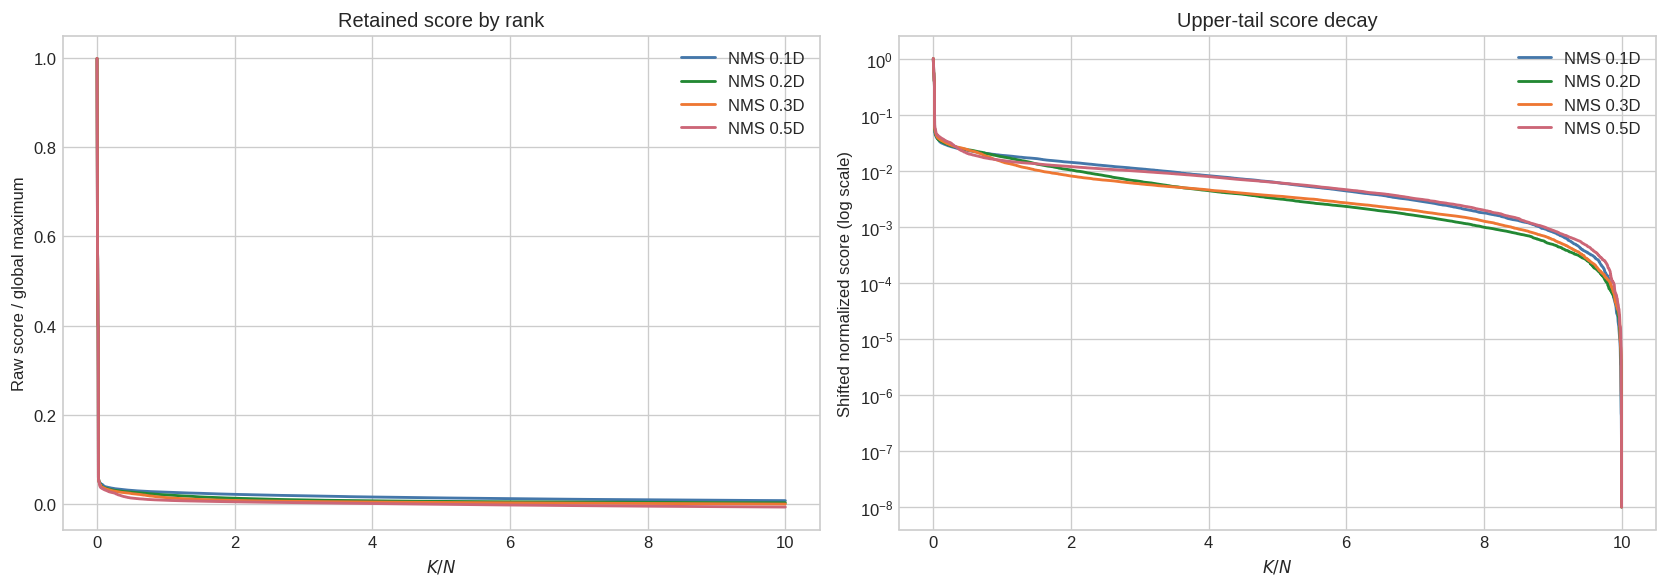

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for fraction, ranked in ranked_by_nms.items():
    normalized_scores = ranked[:, 3] / score_maximum
    axes[0].plot(factors, normalized_scores, lw=1.7, color=colors[fraction], label=f'NMS {fraction:.1f}D')
    axes[1].semilogy(factors, np.maximum(normalized_scores - normalized_scores[-1] + 1e-8, 1e-8),
                    lw=1.7, color=colors[fraction], label=f'NMS {fraction:.1f}D')
axes[0].set(xlabel='$K/N$', ylabel='Raw score / global maximum', title='Retained score by rank')
axes[1].set(xlabel='$K/N$', ylabel='Shifted normalized score (log scale)', title='Upper-tail score decay')
for axis in axes:
    axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'retained_score_decay_by_nms_radius.png', dpi=220)
plt.show()

## 10. Interpretation checklist and additional controls

Use the following checks when interpreting the figures:

- **Ranking versus suppression:** if smaller NMS radii improve recall at the same $K$, the former radius suppressed useful nearby maxima.
- **Localization versus coverage:** if recall collapses for tighter matching radii, high-$K$ recall reflects coarse neighborhood coverage rather than accurate centering.
- **Nonstationarity:** compare per-subvolume q99 and maxima, not only pooled candidate histograms. Strong spatial score fields explain why a global top-$K$ list can be dominated by a few regions.
- **Annotation-free is not noise-only:** high scores there may be genuine unlabeled biology or fiducials. Orthogonal projections of the strongest hotspot cores should be inspected before assigning a cause.
- **Candidate truncation:** stage 7 retained at most 4096 local maxima per subvolume. This is ample for the present top-$10N$ analysis but the score distribution is a truncated local-max distribution, not the full score-field distribution.
- **Recommended null control:** add repeated score-shuffling or spatially constrained random-pick curves. A null must preserve the valid tomogram mask and preferably the per-subvolume candidate density; uniform sampling across the entire rectangular volume would be misleading.
- **Final utility:** coordinate recall is diagnostic. The decisive biological validation remains particle cleanup followed by subtomogram classification, refinement, and FSC-based reconstruction assessment.